# 03_processing_v0

Responsabilite:
- explorer les variables du jeu maritime apres selection de ligne
- tester des transformations et visualisations de pretraitement

Entrees:
- un CSV de ligne, souvent `data/frioul_if.csv`

Sorties:
- figures, tableaux et essais de features dans le notebook

Execution:
- ouvrir le notebook depuis la racine du projet et executer les cellules


In [2]:
import pandas as pd, numpy as np, seaborn as sns, datetime, matplotlib.pyplot as plt, pytz, cartopy.crs as ccrs
from astral.sun import sun
from astral import LocationInfo
from matplotlib.colors import LinearSegmentedColormap
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from pandas.plotting import scatter_matrix

## Récupère maritime_clean.csv


#### Annulation :
- 1 = navette annulée
- 0 = navette desservie

  
#### réformate Date et heure<br>
#### jourNuit
crée une variable continue `jourNuit` (à partir de Horaire) qui indique la distance (en mn) entre l’heure d’observation et le lever ou le coucher du soleil :<br>
- Après le coucher → temps écoulé depuis le coucher du soleil
- Avant le lever → temps avant le lever du soleil (négatif)
- Plein jour → 0<br>

#### Mer
traitée comme une variable ordinale<br>

#### vent et houle
décomposé selon leur orientation<br>

#### cherche des corrélations<br>

a finir<br>

In [4]:
# === PARAMÈTRES GÉNÉRAUX ===
PARIS_TZ = pytz.timezone('Europe/Paris')
MARSEILLE = LocationInfo("Marseille", "France", "Europe/Paris", latitude=43.2965, longitude=5.3698)

CMAP = LinearSegmentedColormap.from_list("green_red", ["green", "lightgrey", "red"], N=256)

# === CONFIGURATION ===
pd.set_option("display.max_columns", None)

# === IMPORT DU FICHIER ===
source = '../data/frioul_if.csv'
df = pd.read_csv(source, index_col=0)

In [5]:
# === CONVERSION DES DATES/HEURES ===
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    df['Mois'] = df['Date'].dt.month

if 'Heure' in df.columns:
    df['Heure'] = pd.to_datetime('2000-01-01 ' + df['Heure'].astype(str), errors='coerce')
    df['Heure_num'] = df['Heure'].dt.hour

if 'Horaire' in df.columns:
    df['Horaire'] = pd.to_datetime(df['Horaire'], errors='coerce')

## JourNuit
Création d'une fonction et une variable<br>
- jour = 0
- Nuit = Int  (nombre de minute depuis/avant le levé/couché du soleil)

In [7]:
# === GESTION FUSEAU HORAIRE ET POSITION ===
paris_tz = pytz.timezone('Europe/Paris')
marseille = LocationInfo("Marseille", "France", "Europe/Paris", latitude=43.2965, longitude=5.3698)

def jourNuit(horaire):
    if pd.isna(horaire):
        return np.nan
    if horaire.tzinfo is None:
        dt_obs = paris_tz.localize(horaire)
    else:
        dt_obs = horaire.astimezone(paris_tz)
    date_obj = dt_obs.date()
    s = sun(marseille.observer, date=date_obj, tzinfo=paris_tz)
    lever = s['sunrise']
    coucher = s['sunset']
    if dt_obs < lever:
        delta = dt_obs - lever
    elif dt_obs > coucher:
        delta = dt_obs - coucher
    else:
        delta = datetime.timedelta(0)
    return round(delta.total_seconds() / 60)

df['JourNuit'] = df['Horaire'].apply(jourNuit)

## Mer
Variable ordinale, de 'ridée' = 0 jusqu'à 'forte' = 4

In [9]:
# === ENCODAGE ORDINAL : état de la mer ===
df['Mer'] = pd.Categorical(
    df['Mer'],
    categories=['ridée', 'belle', 'peu agitée', 'agitée', 'forte'],
    ordered=True
).codes


## Vent
Encodage angulaire de la direction du vent, passe d'une valeur cardinale à une valeur en degré<br>projection de l'angle $\theta$ depuis un cercle<br>
on converti l'angle en x (cosinus), et y (sinus)
|Vents en degrés |Cos en abscisse Est-Ouest, Sin en ordonnée Nord-Sud|
|:-:|:-:|
|![](../img/rose_des_vents.gif)|![](../img/trigo.png)|
|||


In [11]:
# === ENCODAGE DU VENT ET DE LA HOULE ===

# Mapping directions cardinales
directions = {
    'N': 0, 'NNE': 22.5, 'NE': 45, 'ENE': 67.5,
    'E': 90, 'ESE': 112.5, 'SE': 135, 'SSE': 157.5,
    'S': 180, 'SSW': 202.5, 'SW': 225, 'WSW': 247.5,
    'W': 270, 'WNW': 292.5, 'NW': 315, 'NNW': 337.5
}

# Vent : conversion en angle puis en composantes
df['Vent_deg'] = df['Vent'].map(directions)
df['Vent_rad'] = np.deg2rad(df['Vent_deg'])
df['Vent_x'] = np.cos(df['Vent_rad'])
df['Vent_y'] = np.sin(df['Vent_rad'])

# Houle : déjà en degrés
df['Houle_rad'] = np.deg2rad(df['Houle'])
df['Houle_x'] = np.cos(df['Houle_rad'])
df['Houle_y'] = np.sin(df['Houle_rad'])

In [12]:
df.columns

Index(['Horaire', 'Annulation', 'AnnulationMotif', 'Ligne', 'Vent',
       'VentNoeud', 'HouleDominante', 'HouleMax', 'Houle', 'HoulePeriode',
       'Mer', 'Temperature', 'Ciel', 'Bateau', 'Capitaine', 'JourNuit',
       'Vent_deg', 'Vent_rad', 'Vent_x', 'Vent_y', 'Houle_rad', 'Houle_x',
       'Houle_y'],
      dtype='object')

## Houle

## Vent et houle - Angle cible : direction dangereuse
Défini une direction critique (par ex. 315° = NW), et tu mesures l'alignement du vent ou de la houle avec cette direction.

In [15]:
# Détection des directions dangereuses (Mistral : 270°–360° + 0°)
def mistral(angle_deg):
    if angle_deg is None or np.isnan(angle_deg):
        return 0
    angle_deg = angle_deg % 360
    return int(270 <= angle_deg <= 360 or angle_deg == 0)

# Appliquer la logique de danger
df['Vent_deg'] = np.rad2deg(np.arctan2(df['Vent_y'], df['Vent_x'])) % 360
df['VentDanger'] = df['Vent_deg'].apply(mistral)

df['Houle_deg'] = np.rad2deg(np.arctan2(df['Houle_y'], df['Houle_x'])) % 360
df['HouleDanger'] = df['Houle_deg'].apply(mistral)

In [16]:
# === SUPPRESSION DES VARIABLES INTERMÉDIAIRES OU REDONDANTES ===
df.drop(columns=[
    'AnnulationMotif',   # cible inutile
    'Vent', 'Vent_deg', 'Vent_rad', 'Vent_x', 'Vent_y',
    'Houle', 'Houle_deg', 'Houle_rad', 'Houle_x', 'Houle_y'
], errors='ignore', inplace=True)

In [17]:
df.columns

Index(['Horaire', 'Annulation', 'Ligne', 'VentNoeud', 'HouleDominante',
       'HouleMax', 'HoulePeriode', 'Mer', 'Temperature', 'Ciel', 'Bateau',
       'Capitaine', 'JourNuit', 'VentDanger', 'HouleDanger'],
      dtype='object')

In [18]:
df.head()

,Horaire,Annulation,Ligne,VentNoeud,HouleDominante,HouleMax,HoulePeriode,Mer,Temperature,Ciel,Bateau,Capitaine,JourNuit,VentDanger,HouleDanger
0,2023-01-01 06:30:00,0,Vieux Port-Frioul,10.0,1.0,1.8,4.0,2,14.0,Partiellement nuageux,HJEsperandieu,Hellmann Nicolas,-101,0,0
1,2023-01-01 07:05:00,0,Frioul-Vieux Port,8.0,1.1,2.0,5.0,2,14.0,Partiellement nuageux,HJEsperandieu,Hellmann Nicolas,-66,0,0
2,2023-01-01 07:40:00,0,Vieux Port-Frioul,7.0,1.1,1.7,5.0,2,14.0,Partiellement nuageux,HJEsperandieu,Hellmann Nicolas,-31,0,0
3,2023-01-01 08:10:00,0,Frioul-Vieux Port,6.0,1.1,1.9,4.0,2,13.0,Partiellement nuageux,HJEsperandieu,Hellmann Nicolas,-1,0,0
4,2023-01-01 08:45:00,0,Vieux Port-Frioul,10.0,1.2,2.1,4.0,2,15.0,Partiellement nuageux,HJEsperandieu,Hellmann Nicolas,0,0,0


In [19]:
# scatter_matrix(df, figsize=(12, 8))

In [20]:
print("Vent dangereux vs Annulation")
print(pd.crosstab(df['VentDanger'], df['Annulation'], normalize='index'))

print("\nHoule dangereuse vs Annulation")
print(pd.crosstab(df['HouleDanger'], df['Annulation'], normalize='index'))


Vent dangereux vs Annulation
Annulation         0         1
VentDanger                    
0           0.833653  0.166347
1           0.728654  0.271346

Houle dangereuse vs Annulation
Annulation          0         1
HouleDanger                    
0            0.781280  0.218720
1            0.739174  0.260826


In [21]:
print("Taux d'annulation selon vent dangereux :")
print(df.groupby('VentDanger')['Annulation'].mean())

print("\nTaux d'annulation selon houle dangereuse :")
print(df.groupby('HouleDanger')['Annulation'].mean())


Taux d'annulation selon vent dangereux :
VentDanger
0    0.166347
1    0.271346
Name: Annulation, dtype: float64

Taux d'annulation selon houle dangereuse :
HouleDanger
0    0.218720
1    0.260826
Name: Annulation, dtype: float64


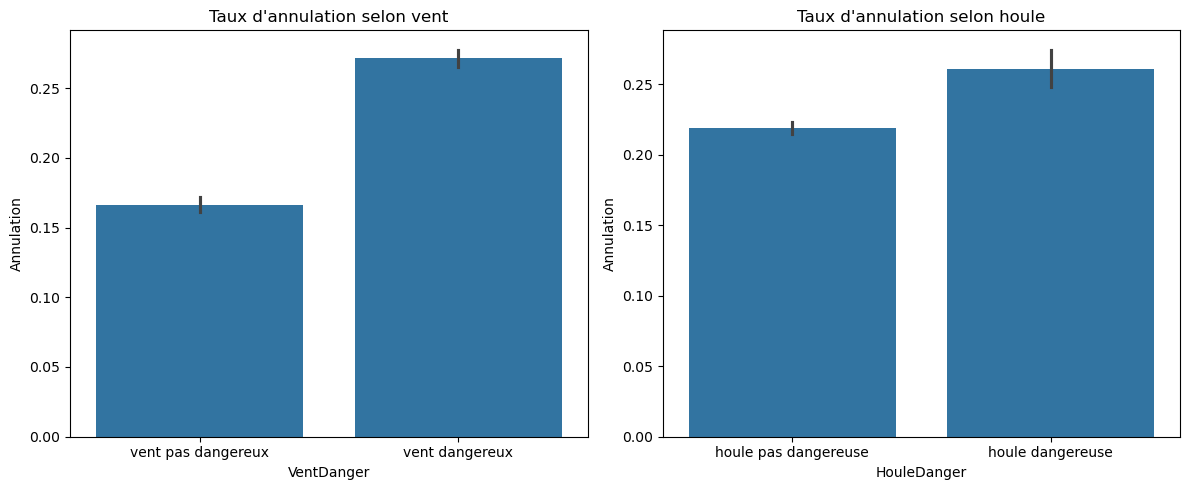

In [22]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(x='VentDanger', y='Annulation', data=df, ax=axs[0])
axs[0].set_title("Taux d'annulation selon vent")
axs[0].set_xticks(axs[0].get_xticks())
axs[0].set_xticklabels(['vent pas dangereux', 'vent dangereux'])

sns.barplot(x='HouleDanger', y='Annulation', data=df, ax=axs[1])
axs[1].set_title("Taux d'annulation selon houle")
axs[1].set_xticks(axs[1].get_xticks())
axs[1].set_xticklabels(['houle pas dangereuse', 'houle dangereuse'])

plt.tight_layout()
plt.show()


## Variables qualitative -> one hot encoder  (plutôt que get_dummies)

In [24]:
df.columns

Index(['Horaire', 'Annulation', 'Ligne', 'VentNoeud', 'HouleDominante',
       'HouleMax', 'HoulePeriode', 'Mer', 'Temperature', 'Ciel', 'Bateau',
       'Capitaine', 'JourNuit', 'VentDanger', 'HouleDanger'],
      dtype='object')

In [25]:
nominal_features = ['Ligne', 'Bateau', 'Ciel', 'Capitaine']
# Initialise l’encodeur
encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
# Encoder les colonnes sélectionnées
encoded_array = encoder.fit_transform(df[nominal_features])
# Récupérer les noms des nouvelles colonnes
encoded_cols = encoder.get_feature_names_out(nominal_features)
# Créer un DataFrame avec les colonnes encodées
encoded_df = pd.DataFrame(encoded_array, columns=encoded_cols, index=df.index)
# Concaténer avec les autres colonnes non encodées
df = pd.concat([df.drop(columns=nominal_features), encoded_df], axis=1)


df_numeric = df.select_dtypes(include=['number'])
df_corr    = df.select_dtypes(include=['number', 'bool'])

In [26]:
df.columns.nunique()

86

## df Numerique

In [28]:
df_numeric = df.select_dtypes(include=['number'])
df_corr    = df.select_dtypes(include=['number', 'bool'])

In [29]:
# df_numeric.columns.nunique()
df_corr.columns.nunique()

85

In [30]:
# Compte les na
# print("Nombre de valeurs manquante par variables :\n",df_numeric.isna().sum(),"\n")
# affiche les na si > 0
print()
print("Liste de variables avec valeurs manquantes :\n",df_numeric.isna().sum()[df_numeric.isna().sum() > 0])


Liste de variables avec valeurs manquantes :
 Series([], dtype: int64)


## Recherche de correlations

In [32]:
corr_matrix = df.corr(numeric_only=True)
target_corr = corr_matrix['Annulation'].sort_values(ascending=False)
print(target_corr)


Annulation                 1.000000
Ligne_Vieux Port-IF        0.376566
Ligne_IF-Frioul            0.376498
Mer                        0.316805
HouleDominante             0.315817
                             ...   
Temperature               -0.054241
JourNuit                  -0.078116
Ciel_Clair                -0.120277
Ligne_Vieux Port-Frioul   -0.281741
Ligne_Frioul-Vieux Port   -0.343096
Name: Annulation, Length: 85, dtype: float64


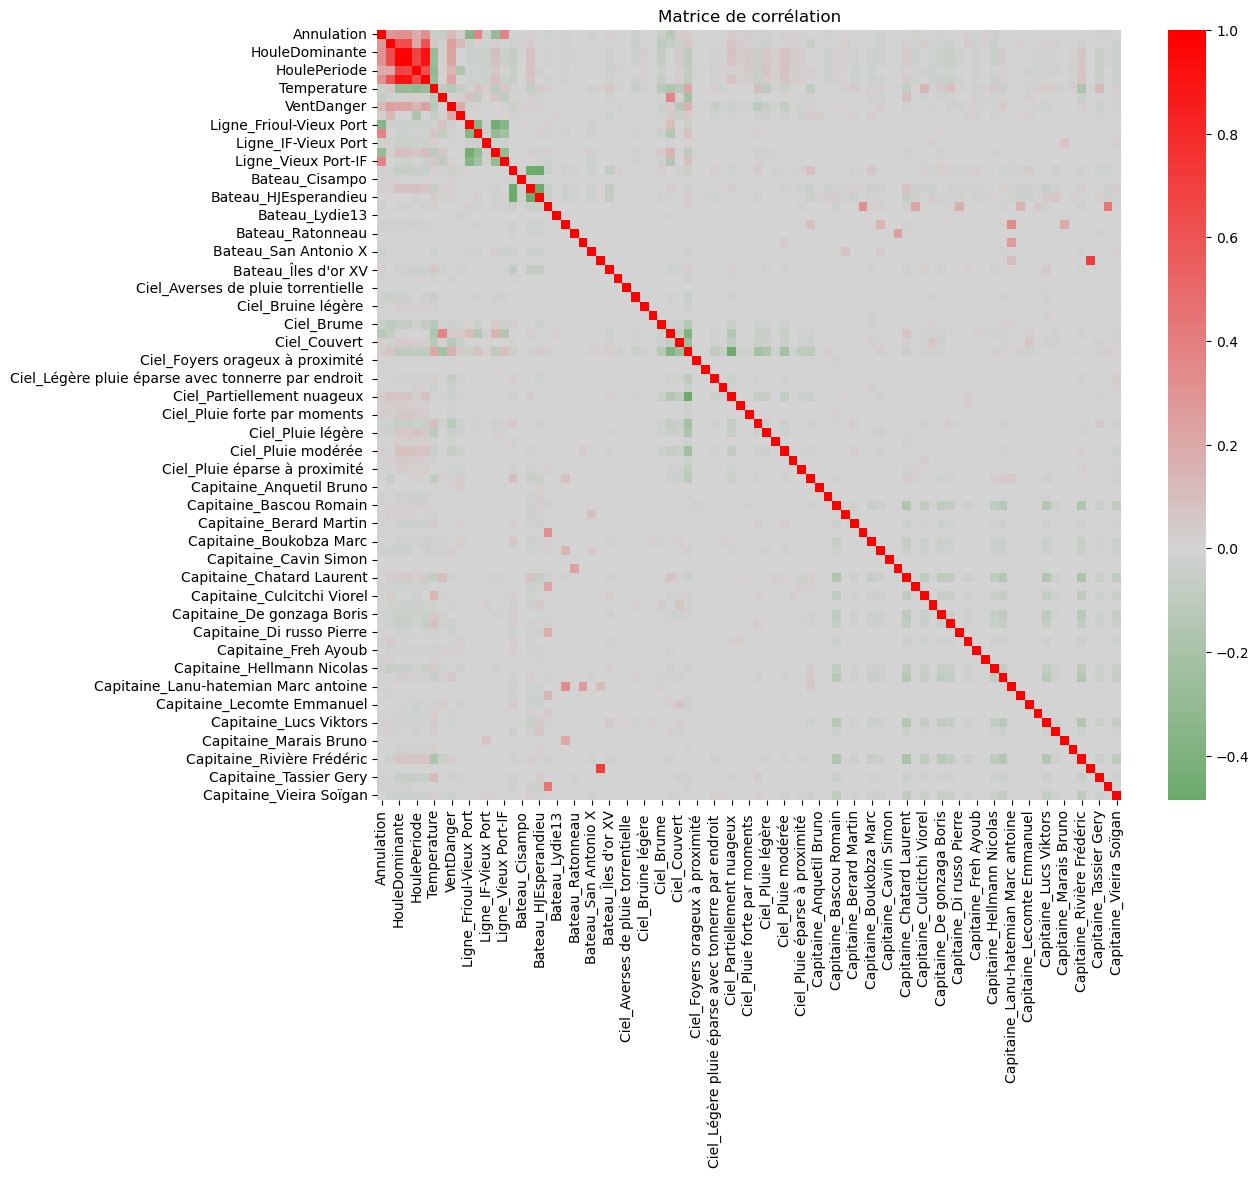

In [33]:
# VISUALISATION
plt.figure(figsize=(12, 10))
sns.heatmap(df_numeric.corr(), cmap=CMAP, center=0, annot=False)
plt.title('Matrice de corrélation')
plt.show()


In [34]:
# CMAP = LinearSegmentedColormap.from_list("green_red", ["green", "white", "red"], N=256)
CMAP = LinearSegmentedColormap.from_list("green_red", ["green", "lightgrey", "red"], N=256)

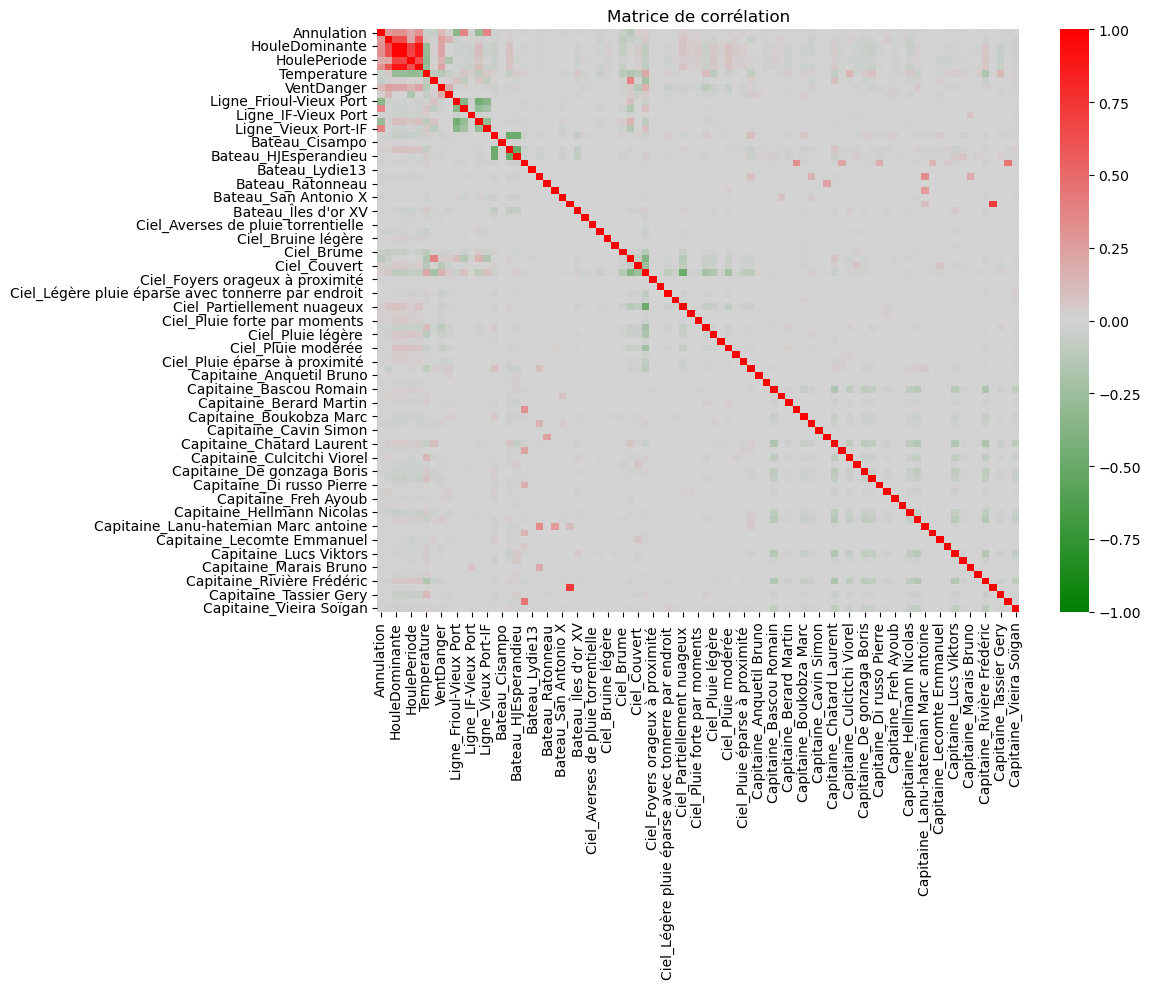

In [35]:
plt.figure(figsize=(12, 10))
sns.heatmap(df_numeric.corr(), cmap=CMAP, center=0, annot=False, vmin=-1, vmax=1)
plt.title('Matrice de corrélation')
# plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("../exports/matrice_de_correlations.png", bbox_inches='tight')

## Trop de variable, la matrice de correlation est illisible

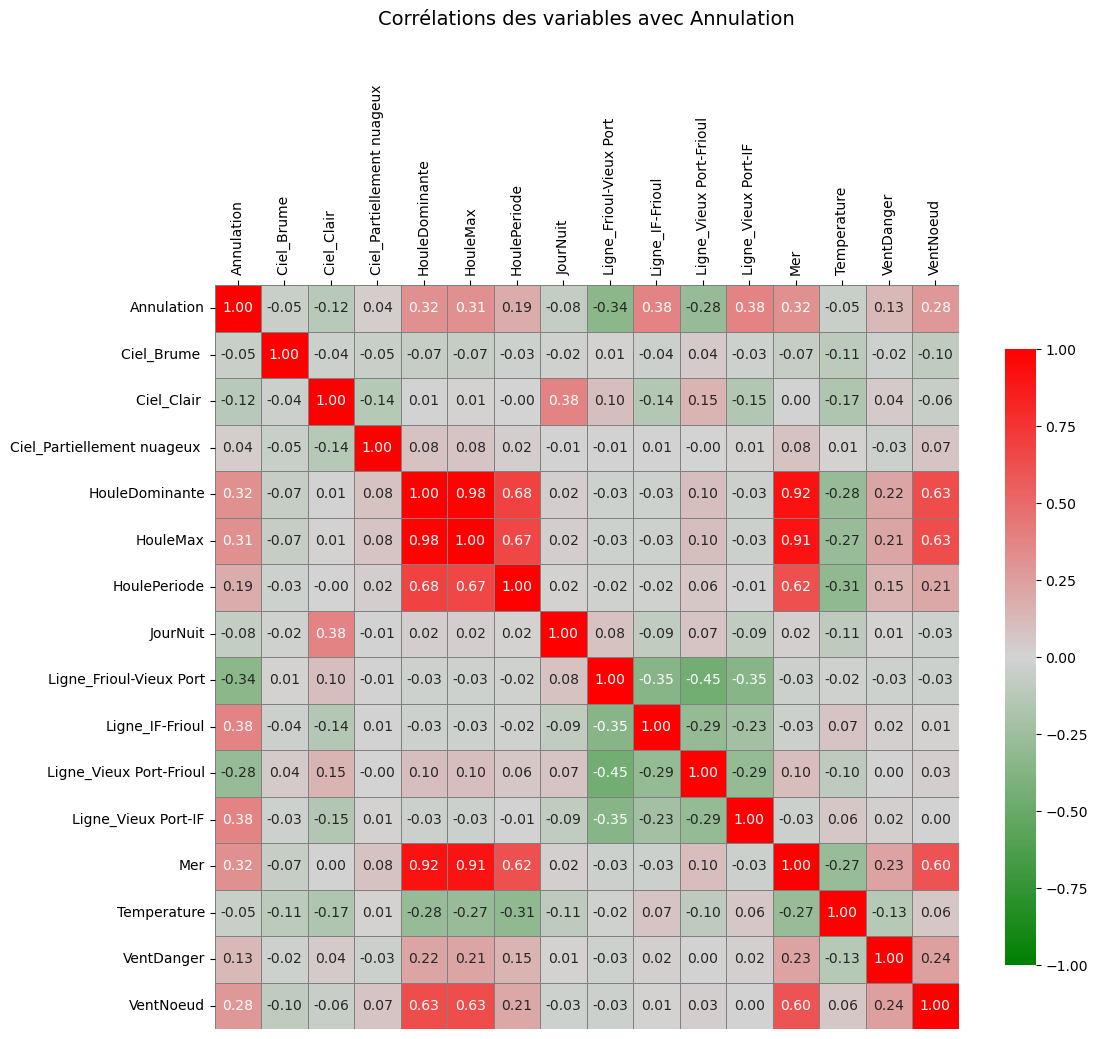

In [37]:
# Choisir les variables les plus pertinentes
SELECTED_VARIABLES = 15

# Calcul de la matrice de corrélation
corr_matrix = df_numeric.corr()

# Variables les plus corrélées avec la cible (hors elle-même)
corr_cible = corr_matrix["Annulation"].drop("Annulation")
top_vars = corr_cible.abs().sort_values(ascending=False).head(SELECTED_VARIABLES).index

# Sous-matrice des corrélations
sub_corr = corr_matrix.loc[top_vars.union(["Annulation"]), top_vars.union(["Annulation"])]

# Affichage avec seaborn heatmap
plt.figure(figsize=(12, 10))
ax = sns.heatmap(
    sub_corr, 
    cmap=CMAP, 
    annot=True,
    vmin=-1,
    vmax=1,
    fmt=".2f",
    center=0,
    linewidths=0.5,
    linecolor='gray',
    square=True,
    cbar_kws={"shrink": 0.8}
)

# Déplacer les labels X en haut
ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')  # Facultatif : pour déplacer le label de l'axe

# Rotation pour lisibilité
plt.xticks(rotation=90)
plt.title("Corrélations des variables avec Annulation", fontsize=14, pad=40)
plt.savefig("../exports/matrice_top_15.png", bbox_inches='tight')
# plt.tight_layout()

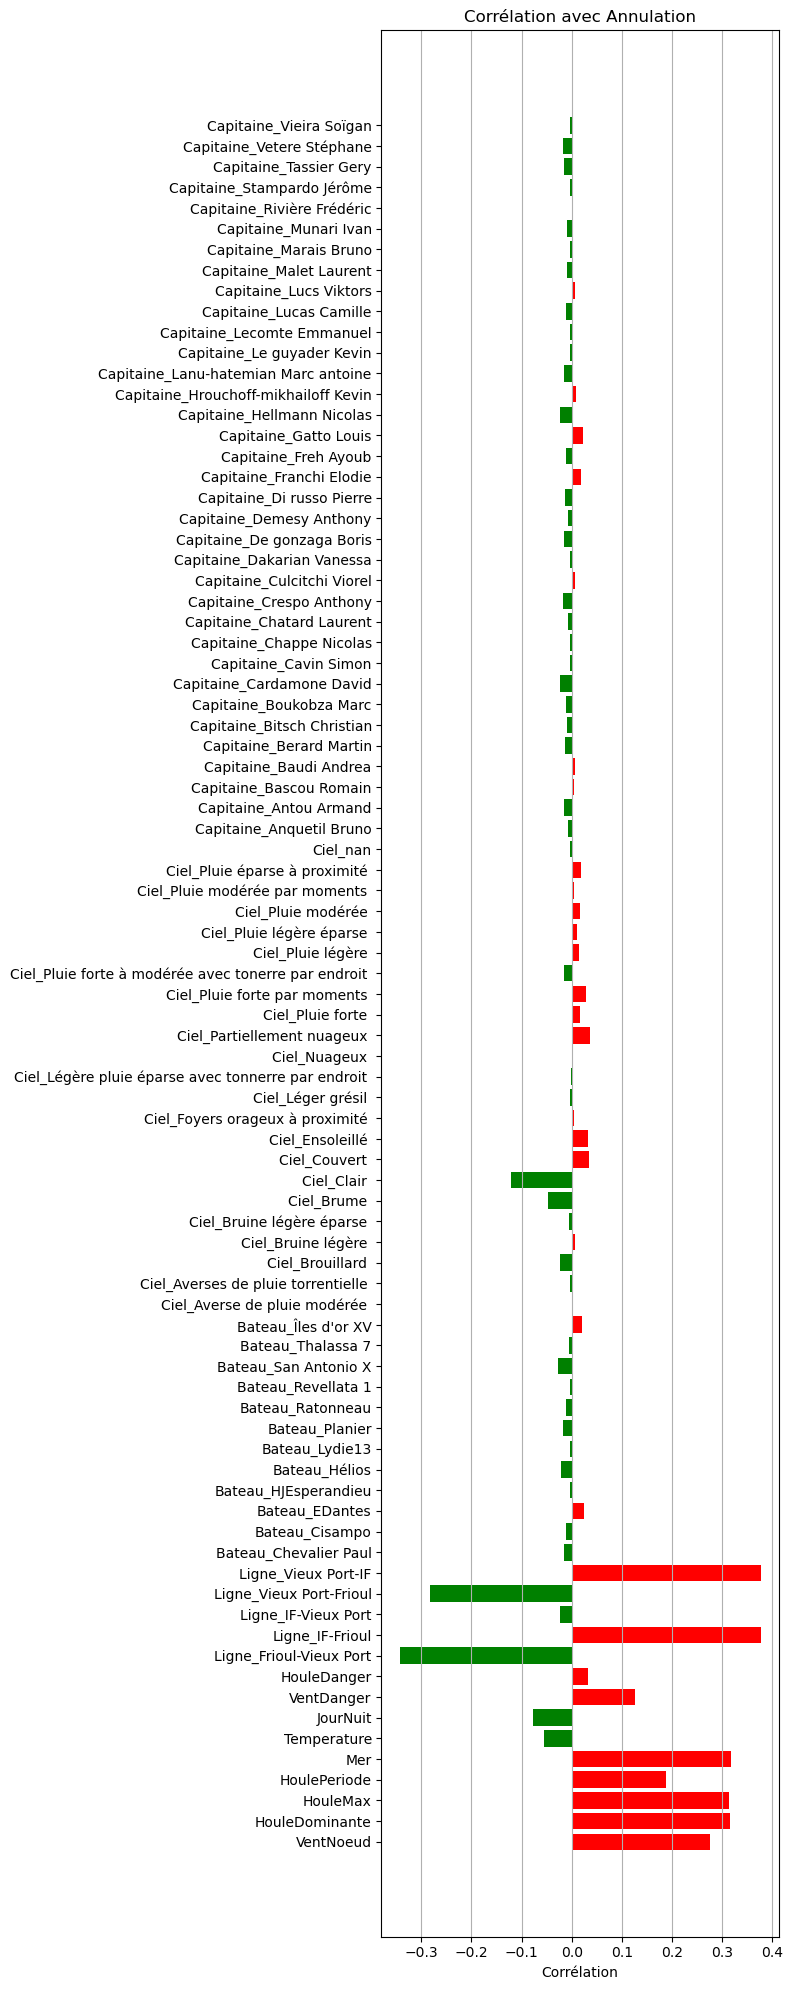

In [38]:
# On récupère les corrélations (hors 'Annulation')
if "Annulation" in corr_cible.index:
    corr_values = corr_cible.drop("Annulation")
else:
    corr_values = corr_cible
variables = corr_values.index
valeurs = corr_values.values

# Applique une couleur différente selon le signe
couleurs = ['green' if v < 0 else 'red' for v in valeurs]

plt.figure(figsize=(8, 20))  # Largeur augmentée pour les étiquettes
bars = plt.barh(variables, valeurs, color=couleurs)
plt.title("Corrélation avec Annulation")
plt.xlabel("Corrélation")
plt.grid(True, axis='x')

plt.tight_layout()  # Ajuste automatiquement la disposition pour éviter le rognage
plt.savefig("../exports/correlations_annulation.png")
plt.show()


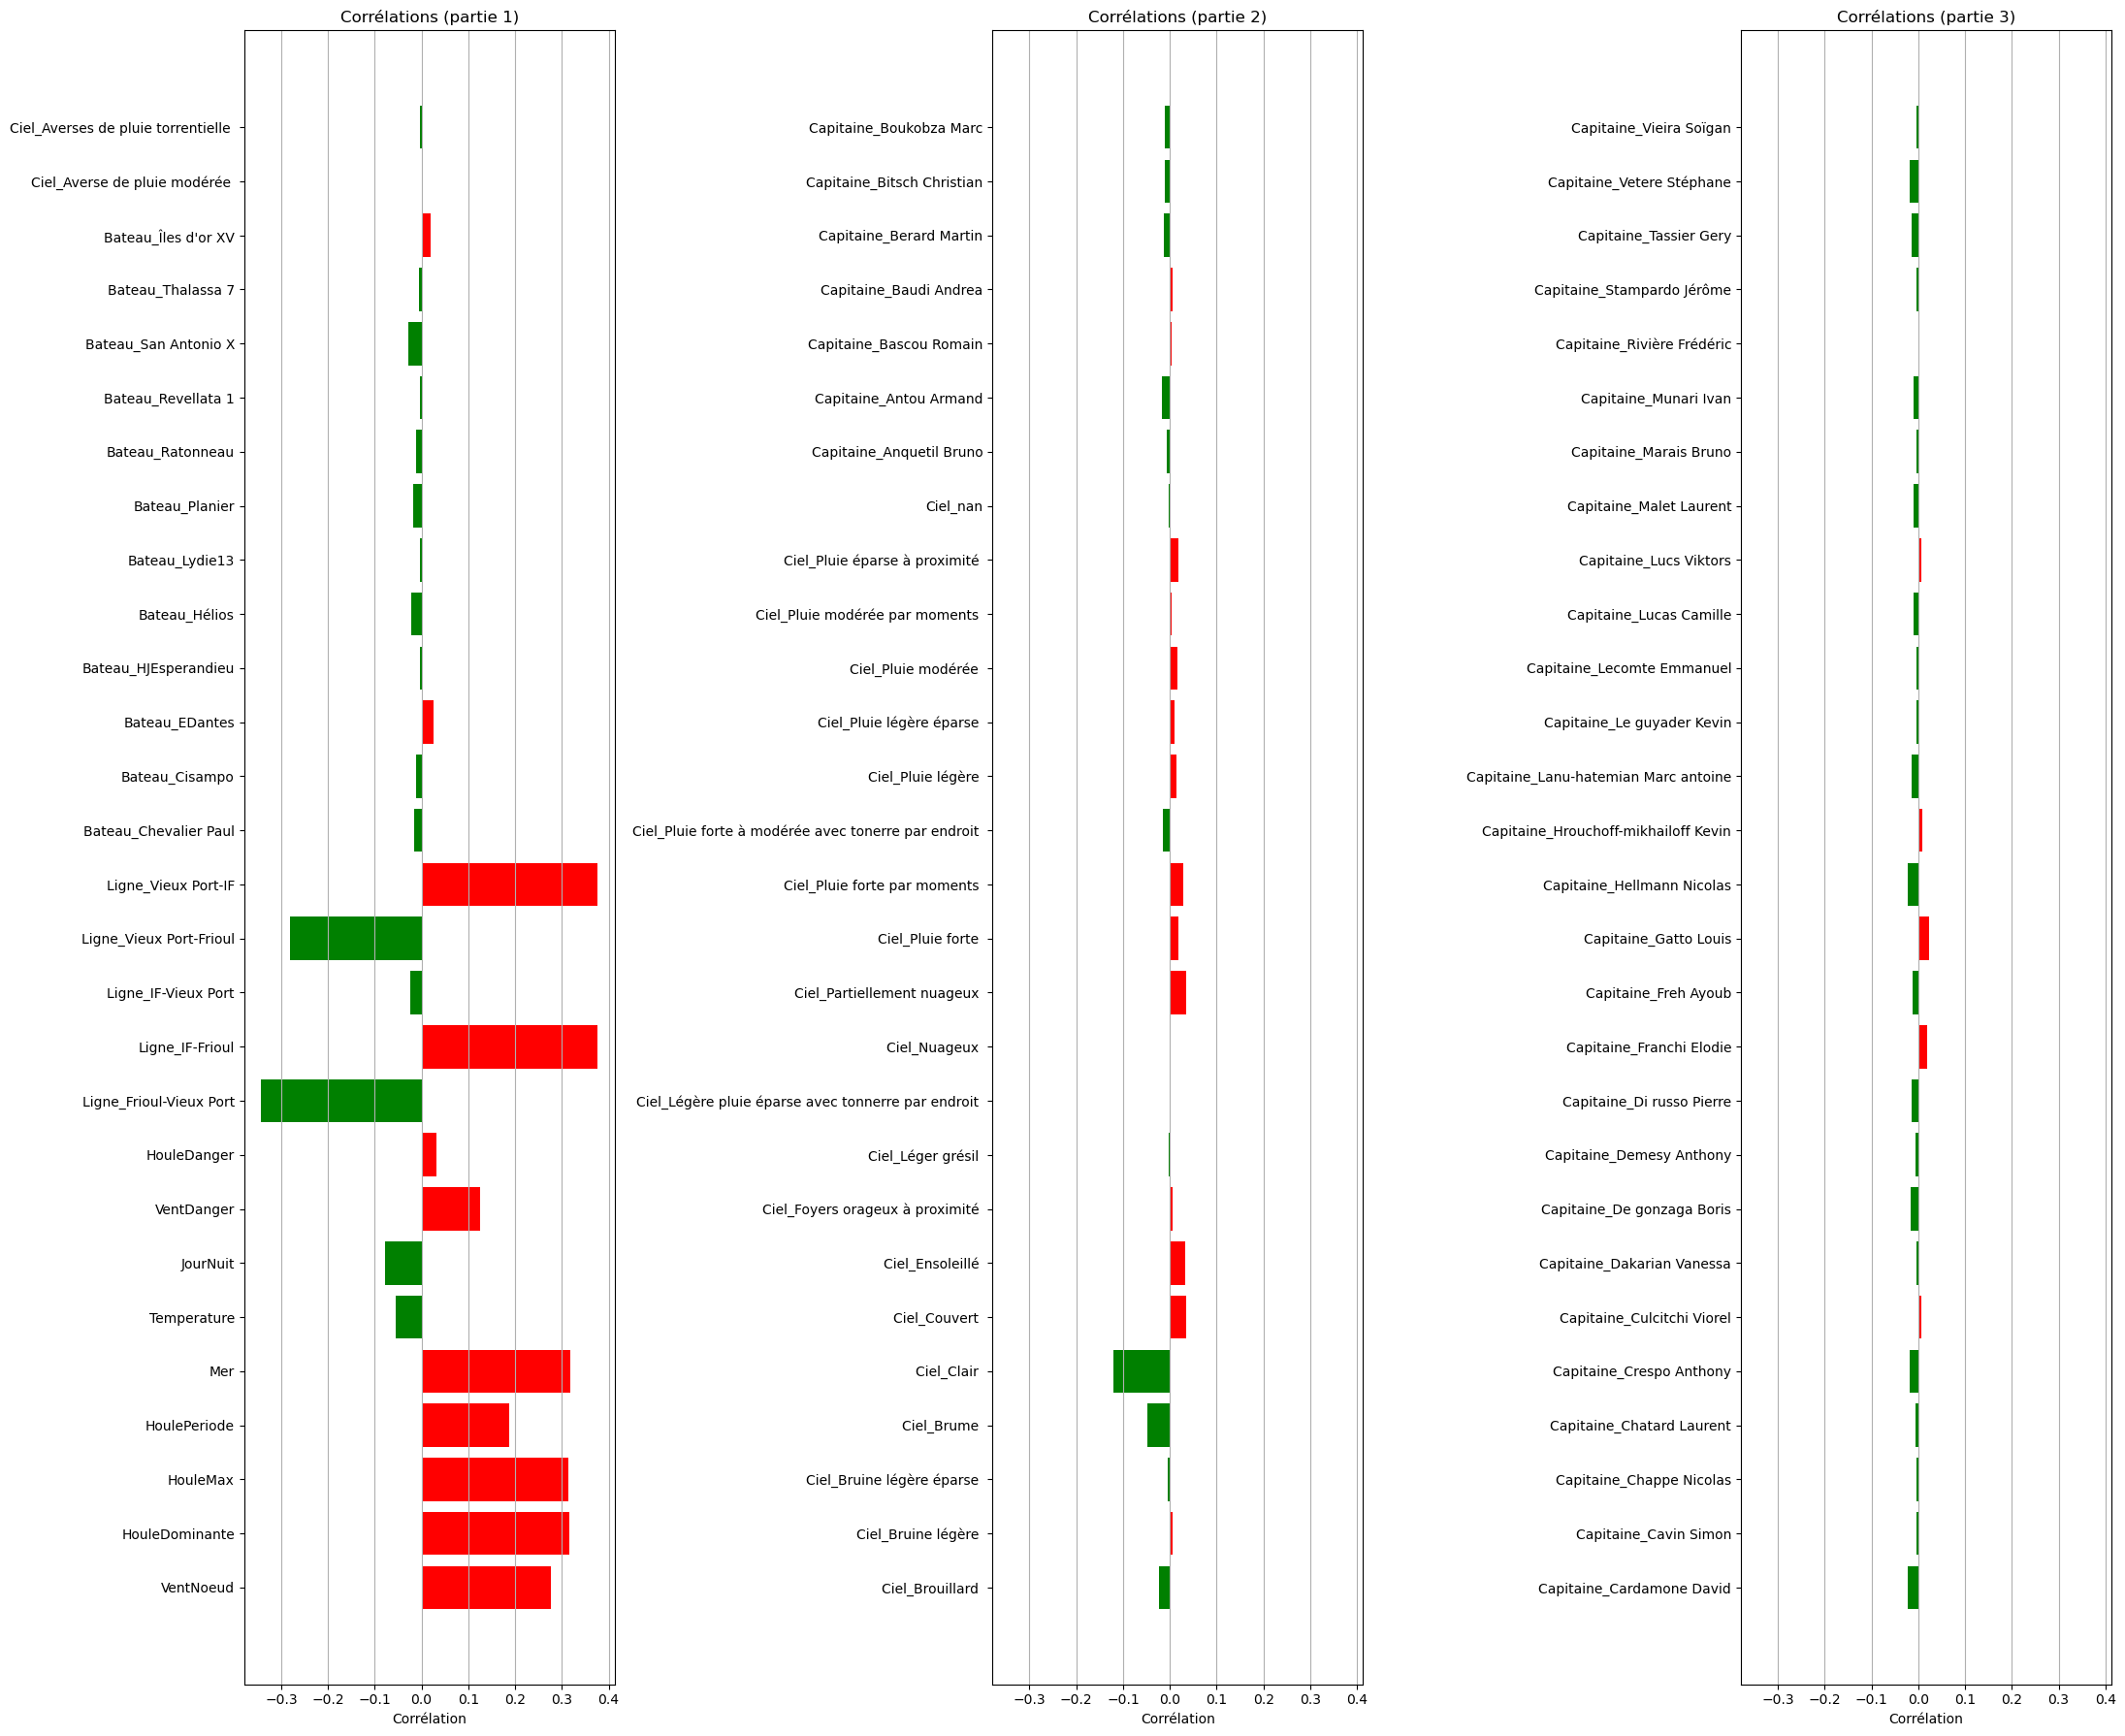

In [ ]:
# corr_values = corr_cible.drop("Annulation")
if "Annulation" in corr_cible.index:
    corr_values = corr_cible.drop("Annulation")
else:
    corr_values = corr_cible
variables = corr_values.index
valeurs = corr_values.values
couleurs = ['green' if v < 0 else 'red' for v in valeurs]

# Fractionnement en 3 parties
n = len(valeurs)
tiers = n // 3

vars_1 = variables[:tiers]
vals_1 = valeurs[:tiers]
cols_1 = couleurs[:tiers]

vars_2 = variables[tiers:2*tiers]
vals_2 = valeurs[tiers:2*tiers]
cols_2 = couleurs[tiers:2*tiers]

vars_3 = variables[2*tiers:]
vals_3 = valeurs[2*tiers:]
cols_3 = couleurs[2*tiers:]

fig, axes = plt.subplots(1, 3, figsize=(22, 18), sharex=True)

axes[0].barh(vars_1, vals_1, color=cols_1)
axes[0].set_title("Corrélations (partie 1)")
axes[0].set_xlabel("Corrélation")
axes[0].grid(True, axis='x')

axes[1].barh(vars_2, vals_2, color=cols_2)
axes[1].set_title("Corrélations (partie 2)")
axes[1].set_xlabel("Corrélation")
axes[1].grid(True, axis='x')

axes[2].barh(vars_3, vals_3, color=cols_3)
axes[2].set_title("Corrélations (partie 3)")
axes[2].set_xlabel("Corrélation")
axes[2].grid(True, axis='x')

plt.tight_layout()
plt.savefig("../exports/correlations_annulation_split3.png")
plt.show()
plt.close()



In [40]:
# Pour une variable catégorielle déjà encodée
def correlation_modalites(df, variable, target='Annulation'):
    modalite_cols = [col for col in df.columns if col.startswith(variable + '_')]
    return df[modalite_cols + [target]].corr()[target].drop(target)

# Exemple d'utilisation
corr_ciel = correlation_modalites(df, 'Ciel')
corr_capitaine = correlation_modalites(df, 'Capitaine')
print(corr_ciel)
print()
print(corr_capitaine)


Ciel_Averse de pluie modérée                            0.002942
Ciel_Averses de pluie torrentielle                     -0.003969
Ciel_Brouillard                                        -0.023216
Ciel_Bruine légère                                      0.006293
Ciel_Bruine légère éparse                              -0.004861
Ciel_Brume                                             -0.047520
Ciel_Clair                                             -0.120277
Ciel_Couvert                                            0.034003
Ciel_Ensoleillé                                         0.033270
Ciel_Foyers orageux à proximité                         0.004964
Ciel_Léger grésil                                      -0.002806
Ciel_Légère pluie éparse avec tonnerre par endroit     -0.000485
Ciel_Nuageux                                            0.001729
Ciel_Partiellement nuageux                              0.035651
Ciel_Pluie forte                                        0.017215
Ciel_Pluie forte par mome

## Séparation des features / cible :

In [42]:
X = df.drop(columns=['Annulation'])
X = X.select_dtypes(include=['number', 'bool'])  # garde uniquement les colonnes utilisables par scikit-learn, suprime datetime
y = df['Annulation']

## modèle 

In [44]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import train_test_split

from sklearn.metrics import classification_report, confusion_matrix

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

model = RandomForestClassifier()
# model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))


# print("Accuracy :", model.score(X_test, y_test))


              precision    recall  f1-score   support

           0       0.95      0.97      0.96      7090
           1       0.90      0.83      0.86      2039

    accuracy                           0.94      9129
   macro avg       0.93      0.90      0.91      9129
weighted avg       0.94      0.94      0.94      9129

